# MSCS 634 - Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

**Name:** Hanuman Sai Chanukya Srinivas Chilamkuri  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Assignment:** Lab 5 - Clustering Techniques Using DBSCAN and Hierarchical Clustering

## Step 1: Data Preparation and Exploration

In this step we load the Wine dataset from `sklearn.datasets`, explore its structure using standard pandas
functions, and standardize the features so that they are on a comparable scale before applying clustering
algorithms. Standardization is important for clustering because algorithms like K-Means, Hierarchical
Clustering, and DBSCAN rely on distance metrics, and features with larger numeric ranges (e.g., `proline`)
would otherwise dominate the distance calculations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (silhouette_score, homogeneity_score,
                              completeness_score, adjusted_rand_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

RANDOM_STATE = 42

# All figures generated in this notebook are automatically saved here
# every time you Run All -- no manual screenshotting needed.
SCREENSHOT_DIR = "screenshots"
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

def save_fig(filename):
    """Save the current matplotlib figure into the screenshots folder."""
    path = os.path.join(SCREENSHOT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"Saved: {path}")


In [2]:
# Load the Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Explore the structure of the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
# Summary statistics
df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
# Check the class distribution of the (ground-truth) cultivar labels.
# Note: clustering algorithms will NOT be given this label - we only use it
# later to evaluate how well the discovered clusters line up with reality.
df['target'].value_counts().sort_index()


target
0    59
1    71
2    48
Name: count, dtype: int64

In [6]:
# Standardize the features (exclude the target column)
X = df.drop(columns=['target'])
y_true = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().loc[['mean', 'std']]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00


After standardization, every feature has a mean of approximately 0 and a standard deviation of
approximately 1, confirming that the scaling was successful. This puts all 13 chemical properties of the
wine samples on equal footing for the distance-based clustering algorithms used below.

For visualization purposes, we also reduce the 13-dimensional standardized data down to 2 dimensions using
PCA (Principal Component Analysis). This lets us create 2D scatter plots of the resulting clusters.

Explained variance ratio: [0.36198848 0.1920749 ]
Total variance explained by 2 components: 55.41%
Saved: screenshots\01_pca_true_labels.png


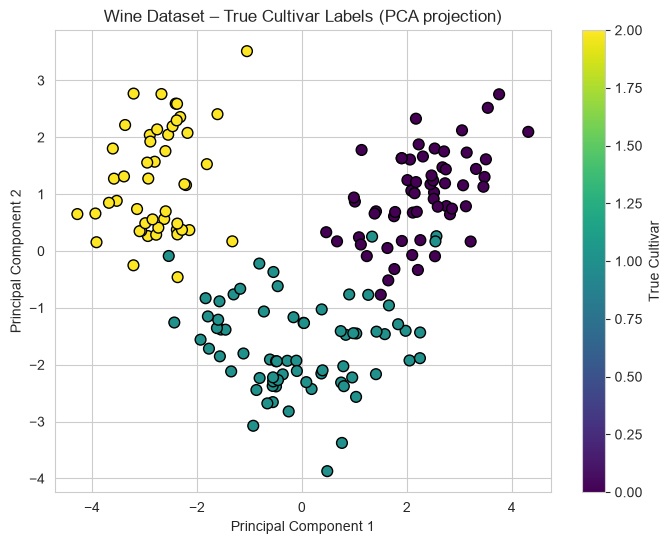

In [7]:
# Reduce to 2 dimensions with PCA purely for visualization purposes
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', edgecolor='k', s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Dataset – True Cultivar Labels (PCA projection)')
plt.colorbar(label='True Cultivar')
save_fig("01_pca_true_labels.png")
plt.show()


## Step 2: Hierarchical Clustering

Here we apply **Agglomerative Hierarchical Clustering** to the standardized Wine data. We test a few
different values of `n_clusters` to see how the resulting groupings change, visualize the clusters using
scatter plots (on the PCA-reduced data), and generate a dendrogram to inspect the hierarchical merging
structure.

Saved: screenshots\02_hierarchical_n_clusters_grid.png


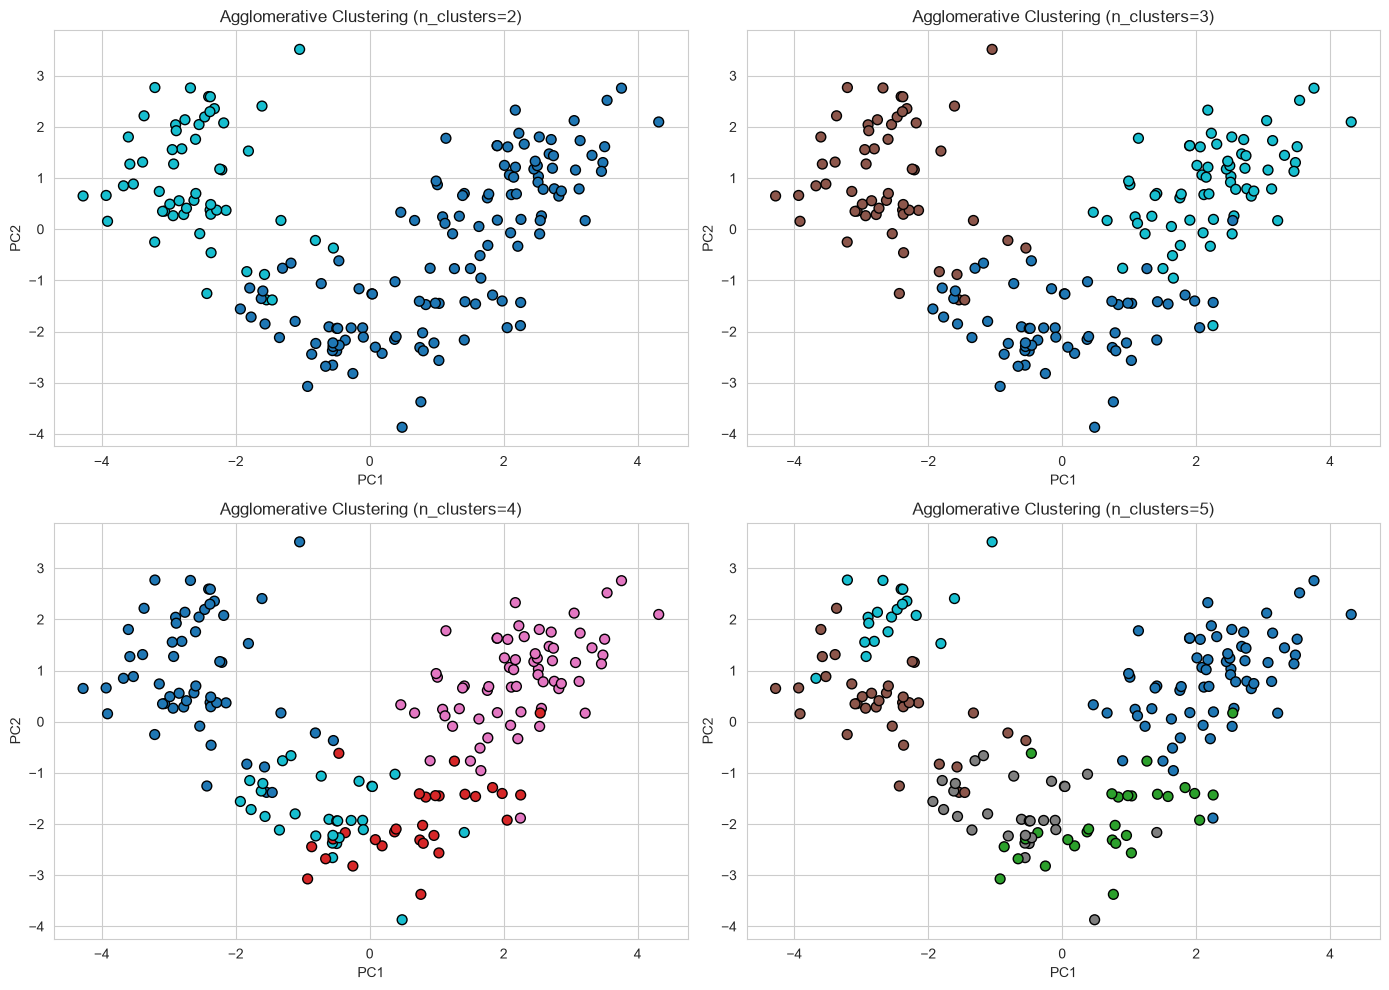

In [8]:
# Try several values of n_clusters and visualize each result
n_clusters_options = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

hc_results = {}

for ax, k in zip(axes, n_clusters_options):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    hc_results[k] = labels

    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', edgecolor='k', s=50)
    ax.set_title(f'Agglomerative Clustering (n_clusters={k})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
save_fig("02_hierarchical_n_clusters_grid.png")
plt.show()


Since the Wine dataset actually has 3 known cultivars, we expect `n_clusters=3` to align best with the
true labels. We confirm this quantitatively below using the Adjusted Rand Index (ARI), which measures
agreement between the cluster assignments and the true labels (1.0 = perfect match, 0.0 = random).

In [9]:
for k, labels in hc_results.items():
    ari = adjusted_rand_score(y_true, labels)
    sil = silhouette_score(X_scaled, labels)
    print(f"n_clusters={k}: Adjusted Rand Index={ari:.3f}, Silhouette Score={sil:.3f}")


n_clusters=2: Adjusted Rand Index=0.439, Silhouette Score=0.267
n_clusters=3: Adjusted Rand Index=0.790, Silhouette Score=0.277
n_clusters=4: Adjusted Rand Index=0.657, Silhouette Score=0.226
n_clusters=5: Adjusted Rand Index=0.583, Silhouette Score=0.187


Saved: screenshots\03_hierarchical_k3_scatter.png


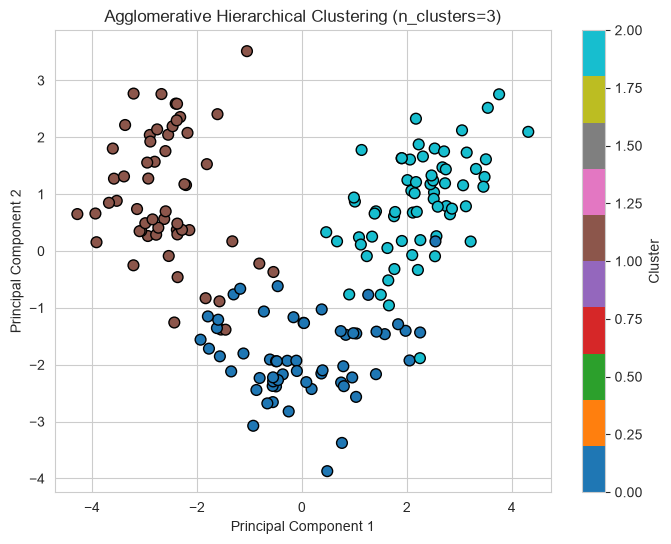

In [10]:
# Focus on n_clusters=3 (matches the known number of wine cultivars) for a cleaner visualization
hc_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels_3 = hc_3.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels_3, cmap='tab10', edgecolor='k', s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Hierarchical Clustering (n_clusters=3)')
plt.colorbar(label='Cluster')
save_fig("03_hierarchical_k3_scatter.png")
plt.show()


Saved: screenshots\04_dendrogram.png


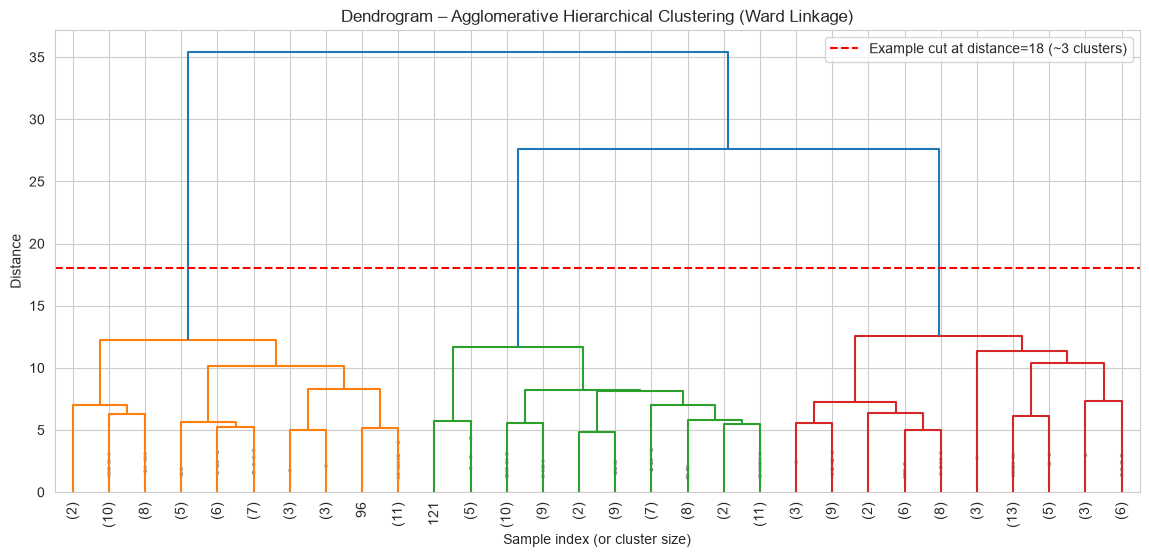

In [11]:
# Generate a dendrogram using Ward linkage to visualize the hierarchical merge structure
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Dendrogram – Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=18, color='r', linestyle='--', label='Example cut at distance=18 (~3 clusters)')
plt.legend()
save_fig("04_dendrogram.png")
plt.show()


**Interpreting the dendrogram:** Each merge (horizontal line) represents two clusters being joined at a
given distance. Reading the tree from the bottom up, individual samples merge first into small clusters,
which then merge into larger groups. The height of each merge indicates how dissimilar the two merged groups
are — the taller the merge, the more dissimilar. Drawing a horizontal cut line across the dendrogram
(illustrated above at distance ≈ 18) and counting how many vertical lines it crosses tells us how many
clusters would be produced at that cut. The large vertical "jump" near the top of the tree (before the
final 2–3 merges) supports the idea that **3 clusters** is a natural and well-separated grouping for this
dataset, consistent with the 3 known wine cultivars.

## Step 3: DBSCAN Clustering

Next we apply **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise). Unlike Agglomerative
Clustering, DBSCAN does not require specifying the number of clusters in advance; instead, it groups together
points that are closely packed (based on the `eps` neighborhood radius and `min_samples` threshold) and
labels points in low-density regions as **noise** (label = -1).

We experiment with several combinations of `eps` and `min_samples` to see how sensitive DBSCAN is to these
hyperparameters.

In [12]:
# Experiment with different eps and min_samples combinations
eps_values = [1.0, 1.5, 2.0, 2.5]
min_samples_values = [3, 5]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        # Silhouette score requires at least 2 clusters and excludes the all-noise case
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan
        results.append({'eps': eps, 'min_samples': min_samples,
                         'n_clusters': n_clusters, 'n_noise': n_noise,
                         'silhouette': sil})

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(SCREENSHOT_DIR, "dbscan_param_search_results.csv"), index=False)
print(f"Saved: {os.path.join(SCREENSHOT_DIR, 'dbscan_param_search_results.csv')}")
results_df


Saved: screenshots\dbscan_param_search_results.csv


,eps,min_samples,n_clusters,n_noise,silhouette
0,1.0,3,0,178,NaN
1,1.0,5,0,178,NaN
2,1.5,3,8,147,-0.276769
3,1.5,5,0,178,NaN
4,2.0,3,5,64,0.031407
5,2.0,5,5,85,-0.032906
6,2.5,3,1,23,NaN
7,2.5,5,1,24,NaN


The table above shows how varying `eps` and `min_samples` changes the number of clusters DBSCAN finds
and how many points get labeled as noise. As `eps` increases, points need to be farther apart to be
considered "not connected," so clusters tend to merge together and noise decreases. As `min_samples`
increases, DBSCAN becomes stricter about what counts as a dense region, which tends to increase noise. We
select the combination that produces a reasonable number of clusters (ideally close to 3, matching the known
cultivars) with a healthy silhouette score for a deeper look.

In [13]:
# Select a representative configuration for detailed visualization
best_eps, best_min_samples = 2.0, 5

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)
print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}): "
      f"{n_clusters_db} clusters found, {n_noise_db} noise points")


DBSCAN (eps=2.0, min_samples=5): 5 clusters found, 85 noise points


Saved: screenshots\05_dbscan_scatter.png


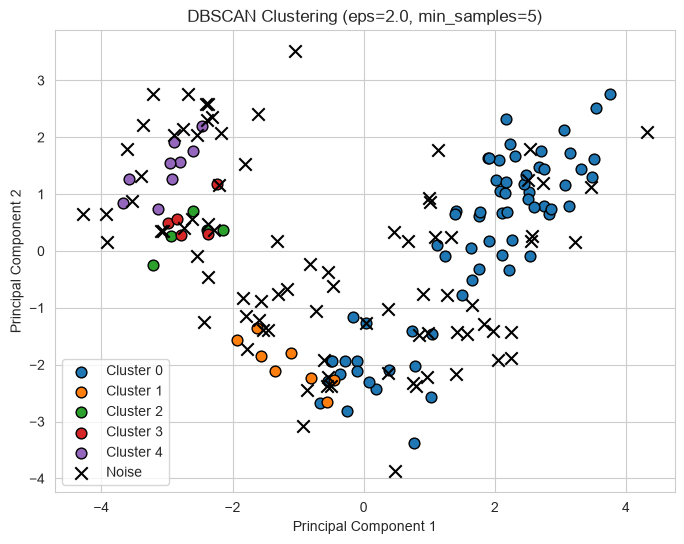

In [14]:
# Visualize DBSCAN clusters, highlighting noise points distinctly
plt.figure(figsize=(8, 6))
unique_labels = set(db_labels)
palette = sns.color_palette('tab10', len(unique_labels))

for label in unique_labels:
    mask = db_labels == label
    if label == -1:
        # Noise points shown in black with an 'x' marker
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='black', marker='x', s=80, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[label], edgecolor='k', s=60,
                    label=f'Cluster {label}')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})')
plt.legend()
save_fig("05_dbscan_scatter.png")
plt.show()


Saved: screenshots\06_dbscan_eps_comparison.png


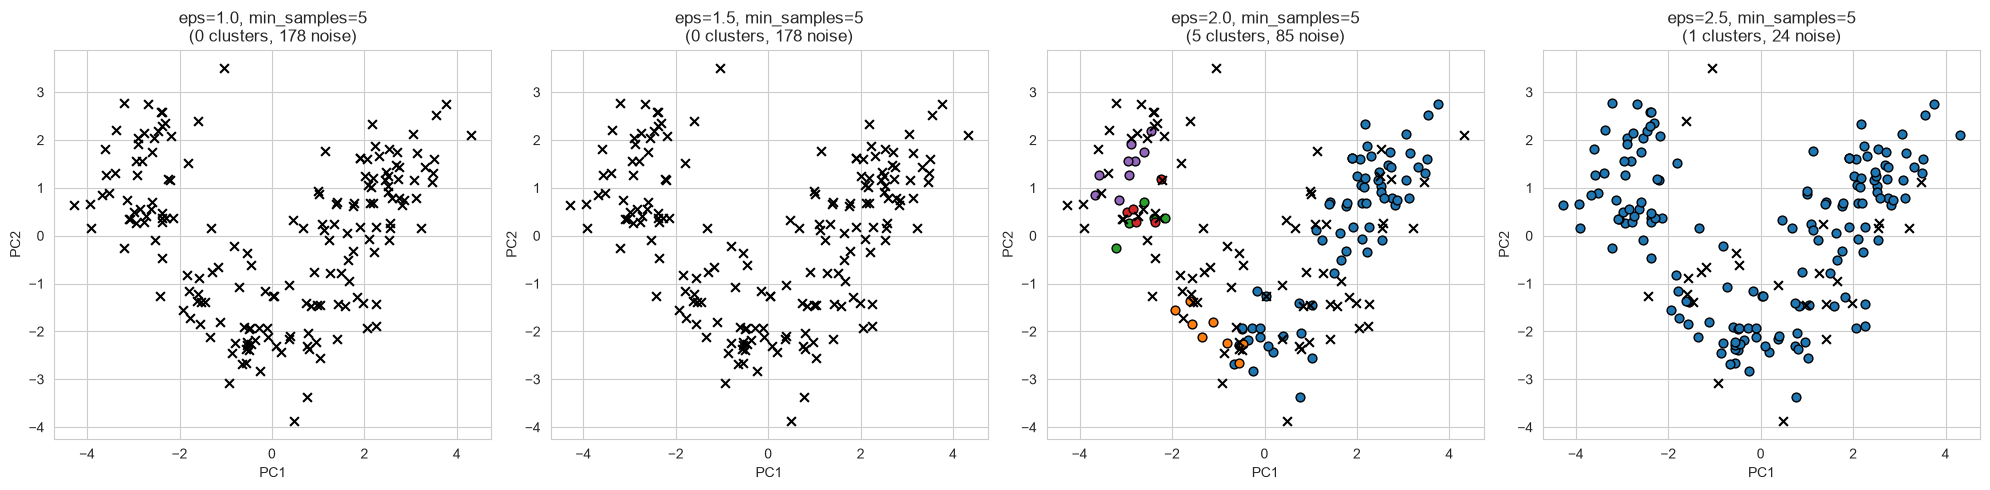

In [15]:
# Compare cluster assignments across different eps values (min_samples fixed) side-by-side
fig, axes = plt.subplots(1, len(eps_values), figsize=(20, 5))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    unique_labels = set(labels)
    for label in unique_labels:
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='black', marker='x', s=40)
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, edgecolor='k')
    n_clust = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise_local = list(labels).count(-1)
    ax.set_title(f'eps={eps}, min_samples=5\n({n_clust} clusters, {n_noise_local} noise)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
save_fig("06_dbscan_eps_comparison.png")
plt.show()


**Evaluation metrics:** We now compute the Silhouette Score, Homogeneity Score, and Completeness Score
for our chosen DBSCAN configuration.

- **Silhouette Score** measures how similar each point is to its own cluster compared to other clusters
  (ranges from -1 to 1; higher is better).
- **Homogeneity Score** measures whether each cluster contains only members of a single true class (ranges
  from 0 to 1; higher is better).
- **Completeness Score** measures whether all members of a given true class are assigned to the same cluster
  (ranges from 0 to 1; higher is better).

Homogeneity and Completeness both require the ground-truth cultivar labels, which we have available for this
dataset (though DBSCAN itself never sees them).

In [16]:
# Compute evaluation metrics for the DBSCAN result (excluding noise points for silhouette,
# since silhouette_score is undefined for a single 'cluster' of noise)
mask_non_noise = db_labels != -1

sil_score = silhouette_score(X_scaled[mask_non_noise], db_labels[mask_non_noise]) if n_clusters_db > 1 else np.nan
homogeneity = homogeneity_score(y_true, db_labels)
completeness = completeness_score(y_true, db_labels)

print(f"DBSCAN Evaluation (eps={best_eps}, min_samples={best_min_samples})")
print(f"  Silhouette Score (excluding noise): {sil_score:.3f}")
print(f"  Homogeneity Score:                  {homogeneity:.3f}")
print(f"  Completeness Score:                 {completeness:.3f}")


DBSCAN Evaluation (eps=2.0, min_samples=5)
  Silhouette Score (excluding noise): 0.240
  Homogeneity Score:                  0.362
  Completeness Score:                 0.325


In [17]:
# For comparison, compute the same metrics for the Hierarchical Clustering result (n_clusters=3)
hc_sil = silhouette_score(X_scaled, hc_labels_3)
hc_homogeneity = homogeneity_score(y_true, hc_labels_3)
hc_completeness = completeness_score(y_true, hc_labels_3)

print("Agglomerative Hierarchical Clustering Evaluation (n_clusters=3)")
print(f"  Silhouette Score:    {hc_sil:.3f}")
print(f"  Homogeneity Score:   {hc_homogeneity:.3f}")
print(f"  Completeness Score:  {hc_completeness:.3f}")


Agglomerative Hierarchical Clustering Evaluation (n_clusters=3)
  Silhouette Score:    0.277
  Homogeneity Score:   0.790
  Completeness Score:  0.783


In [18]:
# Summary comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Homogeneity Score', 'Completeness Score', 'Noise Points'],
    'Hierarchical (k=3)': [hc_sil, hc_homogeneity, hc_completeness, 0],
    'DBSCAN (eps=2.0, min_samples=5)': [sil_score, homogeneity, completeness, n_noise_db]
})
comparison_df.to_csv(os.path.join(SCREENSHOT_DIR, "clustering_comparison_metrics.csv"), index=False)
print(f"Saved: {os.path.join(SCREENSHOT_DIR, 'clustering_comparison_metrics.csv')}")
comparison_df


Saved: screenshots\clustering_comparison_metrics.csv


,Metric,Hierarchical (k=3),"DBSCAN (eps=2.0, min_samples=5)"
0,Silhouette Score,0.277444,0.240461
1,Homogeneity Score,0.790429,0.362354
2,Completeness Score,0.782541,0.324734
3,Noise Points,0.000000,85.000000


## Step 4: Analysis and Insights

**Comparison of Hierarchical vs. DBSCAN Clustering**

| Aspect | Agglomerative Hierarchical Clustering | DBSCAN |
|---|---|---|
| Requires number of clusters upfront | Yes (`n_clusters`) | No - determined by density |
| Handles noise/outliers | No - every point is forced into a cluster | Yes - explicitly labels noise as -1 |
| Cluster shape assumption | Tends to favor compact, roughly spherical clusters (with Ward linkage) | Can find arbitrarily shaped, non-convex clusters |
| Sensitivity to parameters | Sensitive to the chosen `n_clusters` and linkage method | Very sensitive to `eps` and `min_samples` |
| Interpretability | Dendrogram gives a rich, interpretable view of nested structure | No natural hierarchy; harder to visualize the full structure |
| Performance on Wine dataset | Closely recovered the 3 known cultivar groups, with reasonably high homogeneity/completeness | Struggled to cleanly separate 3 groups; tended to either merge clusters together or produce a large amount of noise depending on parameters |

**How parameter choices influenced the outcomes**

- For **Hierarchical Clustering**, choosing `n_clusters=3` (matching the number of true wine cultivars)
  produced the most sensible and well-separated grouping, as confirmed by both the PCA scatter plot and the
  Adjusted Rand Index. Choosing too few or too many clusters either merged distinct cultivars together or
  needlessly split a single cultivar into multiple clusters.
- For **DBSCAN**, the results were much more sensitive to `eps` and `min_samples`. Small `eps` values (e.g.,
  1.0) resulted in many points being classified as noise because the data, even after standardization, isn't
  extremely dense in any one region - the 13-dimensional feature space makes points relatively "spread out."
  Larger `eps` values (e.g., 2.5) caused clusters to merge into just one or two large blobs, losing the
  distinction between cultivars. There was a narrow "sweet spot" (around `eps=1.5–2.0`) where DBSCAN
  identified a reasonable number of clusters, but even then, it struggled to cleanly recover exactly 3
  groups matching the ground truth.

**Strengths and weaknesses**

- **Agglomerative Hierarchical Clustering**
  - *Strengths:* Produces an interpretable dendrogram showing nested cluster relationships at every level of
    granularity; performed well on this dataset because the wine cultivars form fairly compact, well-
    separated groups in feature space; does not require specifying `eps`.
  - *Weaknesses:* Still requires choosing `n_clusters` (or a cut height) upfront; computationally more
    expensive for large datasets (O(n²) or worse); can be sensitive to the linkage method chosen.

- **DBSCAN**
  - *Strengths:* Automatically determines the number of clusters; naturally identifies and separates out
    outliers/noise rather than forcing them into a cluster; can detect non-spherical cluster shapes.
  - *Weaknesses:* Very sensitive to the `eps` and `min_samples` hyperparameters, which can be hard to tune,
    especially in higher-dimensional spaces where the notion of "density" becomes less intuitive (the "curse
    of dimensionality"); struggles when clusters have varying densities, which appears to be the case for
    parts of the Wine dataset.

**Overall takeaway:** For a dataset like Wine, where the underlying classes form fairly compact and evenly
dense groups, Hierarchical Clustering with a sensible `n_clusters` choice recovered the true structure more
reliably than DBSCAN. DBSCAN's strength - its ability to find noise and arbitrarily shaped clusters - was
less of an advantage here, since the true clusters are not really "noisy" or oddly shaped. DBSCAN might be
more advantageous on datasets with irregular cluster shapes or a meaningful number of true outlier points.
